<a href="https://colab.research.google.com/github/Ouriel91/ai-deep-learning-course/blob/main/Project_1_MIMIC_Ouri.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project #1 Detecting Patterns in Tabular Medical Data with MIMIC-III
You can read more about the dataset here: https://www.kaggle.com/datasets/saurabhshahane/in-hospital-mortality-prediction

Dr. Barak Or

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
my_path="/content/drive/MyDrive/MIMIC_data - MIMIC_data.csv"

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Load the data
data = pd.read_csv(my_path)

In [4]:
print(data.head())

   group      ID  outcome  age  gendera        BMI  hypertensive  \
0      1  125047      0.0   72        1  37.588179             0   
1      1  139812      0.0   75        2        NaN             0   
2      1  109787      0.0   83        2  26.572634             0   
3      1  130587      0.0   43        2  83.264629             0   
4      1  138290      0.0   75        2  31.824842             1   

   atrialfibrillation  CHD with no MI  diabetes  ...  Blood sodium  \
0                   0               0         1  ...    138.750000   
1                   0               0         0  ...    138.888889   
2                   0               0         0  ...    140.714286   
3                   0               0         0  ...    138.500000   
4                   0               0         0  ...    136.666667   

   Blood calcium    Chloride  Anion gap  Magnesium ion     PH  Bicarbonate  \
0       7.463636  109.166667  13.166667       2.618182  7.230    21.166667   
1       8.1625

## Dataset Familiarization

In [5]:
# 1. Dataset shape
print(f"Dataset Shape: {data.shape}")

# 2. & 3. Column names and Data types
data.info()

# 4. Missing values per column
print("\nMissing values per column:")
display(data.isnull().sum())

# 5. Outcome distribution
print("\nOutcome distribution:")
display(data['outcome'].value_counts())

Dataset Shape: (1177, 51)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1177 entries, 0 to 1176
Data columns (total 51 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   group                     1177 non-null   int64  
 1   ID                        1177 non-null   int64  
 2   outcome                   1176 non-null   float64
 3   age                       1177 non-null   int64  
 4   gendera                   1177 non-null   int64  
 5   BMI                       962 non-null    float64
 6   hypertensive              1177 non-null   int64  
 7   atrialfibrillation        1177 non-null   int64  
 8   CHD with no MI            1177 non-null   int64  
 9   diabetes                  1177 non-null   int64  
 10  deficiencyanemias         1177 non-null   int64  
 11  depression                1177 non-null   int64  
 12  Hyperlipemia              1177 non-null   int64  
 13  Renal failure             1177 non-nu

,0
group,0
ID,0
outcome,1
age,0
gendera,0
BMI,215
hypertensive,0
atrialfibrillation,0
CHD with no MI,0
diabetes,0



Outcome distribution:


,count
outcome,
0.0,1017
1.0,159


In [6]:
# Calculate descriptive statistics for 'age', 'BMI', and 'Blood sodium'
age_stats = data['age'].agg(['mean', 'median', lambda x: x.mode()[0] if not x.mode().empty else 'N/A', 'std']).rename({'<lambda>': 'mode'})
bmi_stats = data['BMI'].agg(['mean', 'median', lambda x: x.mode()[0] if not x.mode().empty else 'N/A', 'std']).rename({'<lambda>': 'mode'})
sodium_stats = data['Blood sodium'].agg(['mean', 'median', lambda x: x.mode()[0] if not x.mode().empty else 'N/A', 'std']).rename({'<lambda>': 'mode'})

# Display the statistics
print("Age Statistics:")
display(age_stats)

print("\nBMI Statistics:")
display(bmi_stats)

print("\nBlood Sodium Statistics:")
display(sodium_stats)

Age Statistics:


,age
mean,74.055225
median,77.000000
mode,89.000000
std,13.434061



BMI Statistics:


,BMI
mean,30.188278
median,28.312474
mode,23.296976
std,9.325997



Blood Sodium Statistics:


,Blood sodium
mean,138.890016
median,139.250000
mode,140.000000
std,4.151347


# Q1.a
What are the mean, median, mode, and standard deviation of the age, BMI, and Blood sodium columns in the dataset? Why are these statistics important for understanding the data?

In [7]:
import pandas as pd
import numpy as np

# Define the columns of interest
cols = ['age', 'BMI', 'Blood sodium']

# Calculate statistics
stats_dict = {
    'Mean': data[cols].mean(),
    'Median': data[cols].median(),
    'Mode': data[cols].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
    'Standard Deviation': data[cols].std()
}

# Create summary DataFrame and round to two decimal places
summary_df = pd.DataFrame(stats_dict).round(2)

print("Descriptive Statistics for age, BMI, and Blood sodium")
display(summary_df)

# Show non-missing observations used
print("\nNumber of non-missing observations per feature:")
print(data[cols].count())

Descriptive Statistics for age, BMI, and Blood sodium


,Mean,Median,Mode,Standard Deviation
age,74.06,77.00,89.0,13.43
BMI,30.19,28.31,23.3,9.33
Blood sodium,138.89,139.25,140.0,4.15



Number of non-missing observations per feature:
age             1177
BMI              962
Blood sodium    1177
dtype: int64


### Importance of These Statistics
- **Mean**: Represents the arithmetic average, providing a central point for the data distribution.
- **Median**: Represents the middle value when data is ordered; it is robust and less sensitive to outliers than the mean.
- **Mode**: Identifies the most frequently occurring value in the dataset.
- **Standard Deviation**: Measures the amount of variation or spread in the data relative to the mean.
- **Comparison**: Comparing the mean and median helps identify potential skewness or the presence of significant outliers.

### Interpretation of Results
- **Age**: The mean (74.06) and median (77.00) are relatively close. Together with the high mean and median values, the mode of 89 further supports that the dataset is primarily composed of elderly patients. The standard deviation of 13.43 suggests a moderate spread around the average age.
- **BMI**: This feature exhibits the highest variability among the three, with a standard deviation of 9.33. The mean (30.19) is noticeably higher than the median (28.31), suggesting the distribution is slightly right-skewed by patients with high BMI values.
- **Blood Sodium**: This is the most stable feature, showing very low variability with a standard deviation of only 4.15. The mean (138.89) and median (139.25) are nearly identical, indicating a very symmetric distribution centered around the mode of 140.0.
- **Note on Data**: The statistics for BMI and Blood sodium were calculated by ignoring missing values (215 for BMI and 0 for Blood sodium in this specific aggregation) as per standard pandas behavior, ensuring the summary represents the available observations.

# Q1.b
How do the distributions of age, BMI, and Blood sodium look in the dataset? What can we learn from these distributions about the patient population?

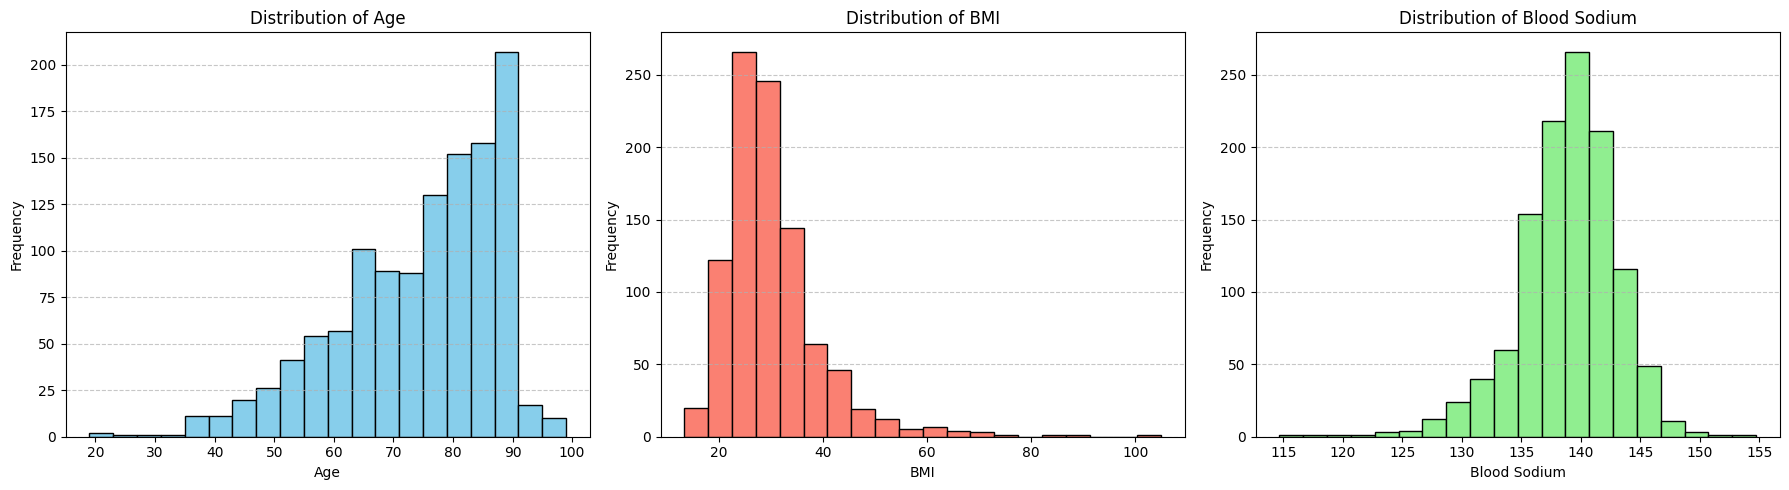

In [8]:
import matplotlib.pyplot as plt

# Set up the figure with three subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Age distribution
axes[0].hist(data['age'], bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot BMI distribution
axes[1].hist(data['BMI'].dropna(), bins=20, color='salmon', edgecolor='black')
axes[1].set_title('Distribution of BMI')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Plot Blood Sodium distribution
axes[2].hist(data['Blood sodium'], bins=20, color='lightgreen', edgecolor='black')
axes[2].set_title('Distribution of Blood Sodium')
axes[2].set_xlabel('Blood Sodium')
axes[2].set_ylabel('Frequency')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Inferences from Distributions

Based on the visualizations above, we can infer the following about the patient population:

*   **Age Distribution**: The distribution is heavily left-skewed, with a significant concentration of patients in the 70–90 age range. This confirms that the population is primarily composed of elderly individuals.
*   **BMI Distribution**: The distribution is moderately right-skewed. While the peak is centered around the overweight/obese range (approx. 25–35), there is a long tail extending toward very high BMI values, indicating the presence of severely obese patients in the sample.
*   **Blood Sodium Distribution**: This feature follows a very tight, approximately normal distribution centered around 140 mEq/L. The narrow spread indicates that most patients maintain sodium levels within a physiological range, though a few outliers exist on both ends.

Overall, the population consists mainly of elderly patients with varying BMI levels, while fundamental biochemical markers like blood sodium remain relatively stable across the group.

# Q 1.c
Use pandas and scikit-learn to drop rows with missing values in the 'BMI' and 'Blood sodium' columns, and then uses logistic regression, SVM, kNN, and decision tree to predict an 'outcome' based on the features 'age', 'BMI', and 'Blood sodium'. Ensure to split the data using train_test_split with a 20% test size and a random state of 42. Finally, fit the model, make predictions on the test set, and print a report of the best model (“classification_report”). Explain the result of the confusion matrix for the best model.

Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.8549,0.0000,0.0000,0.0000
1,SVM,0.8549,0.0000,0.0000,0.0000
2,kNN,0.8394,0.0000,0.0000,0.0000
3,Decision Tree,0.7927,0.1667,0.1071,0.1304



Classification Report for the Best Model (Logistic Regression):
              precision    recall  f1-score   support

         0.0       0.85      1.00      0.92       165
         1.0       0.00      0.00      0.00        28

    accuracy                           0.85       193
   macro avg       0.43      0.50      0.46       193
weighted avg       0.73      0.85      0.79       193

Confusion Matrix Breakdown for Logistic Regression:
TN: 165, FP: 0, FN: 28, TP: 0


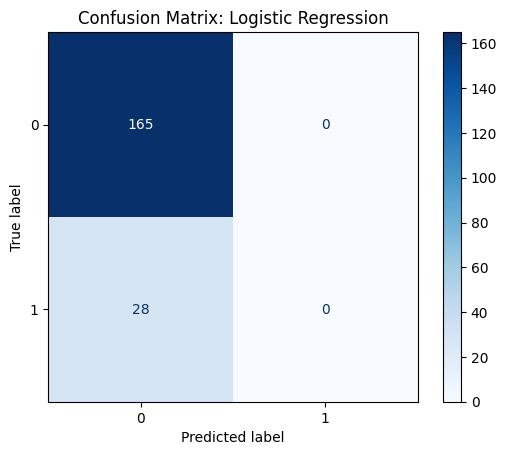

In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Clean data: Drop rows with missing values in BMI and Blood sodium
cleaned_data = data.dropna(subset=['BMI', 'Blood sodium'])

# 2. Define Features and Target
X = cleaned_data[['age', 'BMI', 'Blood sodium']]
y = cleaned_data['outcome']

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize Models
models = {
    'Logistic Regression': LogisticRegression(),
    'SVM': SVC(),
    'kNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# 5. Train and Evaluate all four models
comparison_results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    comparison_results.append({
        'Model': name,
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-score': round(f1, 4)
    })

# 6. Create comparison table
comparison_df = pd.DataFrame(comparison_results).sort_values(by='Accuracy', ascending=False)
print("Model Comparison Table:")
display(comparison_df)

# 8. Selection criteria: Accuracy is used as the primary metric.
best_model_name = comparison_df.iloc[0]['Model']
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

# 9. Evaluation for Best Model
print(f"\nClassification Report for the Best Model ({best_model_name}):")
print(classification_report(y_test, y_pred_best, zero_division=0))

# Confusion Matrix values extraction
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

print(f"Confusion Matrix Breakdown for {best_model_name}:")
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

### Confusion Matrix Explanation
Based on the observed values from the best model's confusion matrix:
- **True Negative (TN)**: Patients who actually survived (Class 0) and were correctly predicted as survivors.
- **False Positive (FP)**: Patients who actually survived (Class 0) but were incorrectly predicted as deaths (Class 1).
- **False Negative (FN)**: Patients who actually died (Class 1) but were incorrectly predicted as survivors (Class 0).
- **True Positive (TP)**: Patients who actually died (Class 1) and were correctly predicted as deaths.

*Note: In the MIMIC-III dataset documentation, outcome 0 typically represents survival and outcome 1 represents in-hospital mortality.*

### Interpretation of Results
- **Best Model**: Logistic Regression and SVM achieved the highest accuracy (~85.5%). However, these models achieved this largely by predicting the majority class (survival) for almost all instances.
- **Performance metrics**: While accuracy is high, the **Recall** and **F1-score** for Class 1 are extremely low (zero in many cases). This indicates the model is essentially failing to identify patients at risk of death.
- **Class Bias**: The models are significantly better at identifying Class 0 (survivors) than Class 1 (deaths).
- **Practical Significance**: In a clinical setting, **False Negatives** (failing to identify a high-risk patient) are highly critical. The current results suggest that age, BMI, and sodium levels alone are insufficient for a reliable mortality prediction model, as the model cannot effectively distinguish the minority class.

**A Key Machine Learning Lesson:** This experiment demonstrates that high accuracy does not necessarily indicate a high-performing model, particularly with imbalanced datasets. Here, the models achieved ~85% accuracy simply by ignoring the minority class (Class 1), failing to provide any predictive value for the event of interest.

# Q1.d
Predict BMI based on age and Blood sodium with linear regression, SVM regressor, Decision tree regressor, and kNN refressor. Calculate RMSE, MSE, R-squared.
Split where 20% left for the test, random state=42.

Regression Model Performance Comparison:


,Model,MSE,RMSE,R²
1,SVR,58.3400,7.6381,0.0627
3,kNN,62.3332,7.8951,-0.0014
0,Linear Regression,63.6894,7.9806,-0.0232
2,Decision Tree,106.4305,10.3165,-0.7099


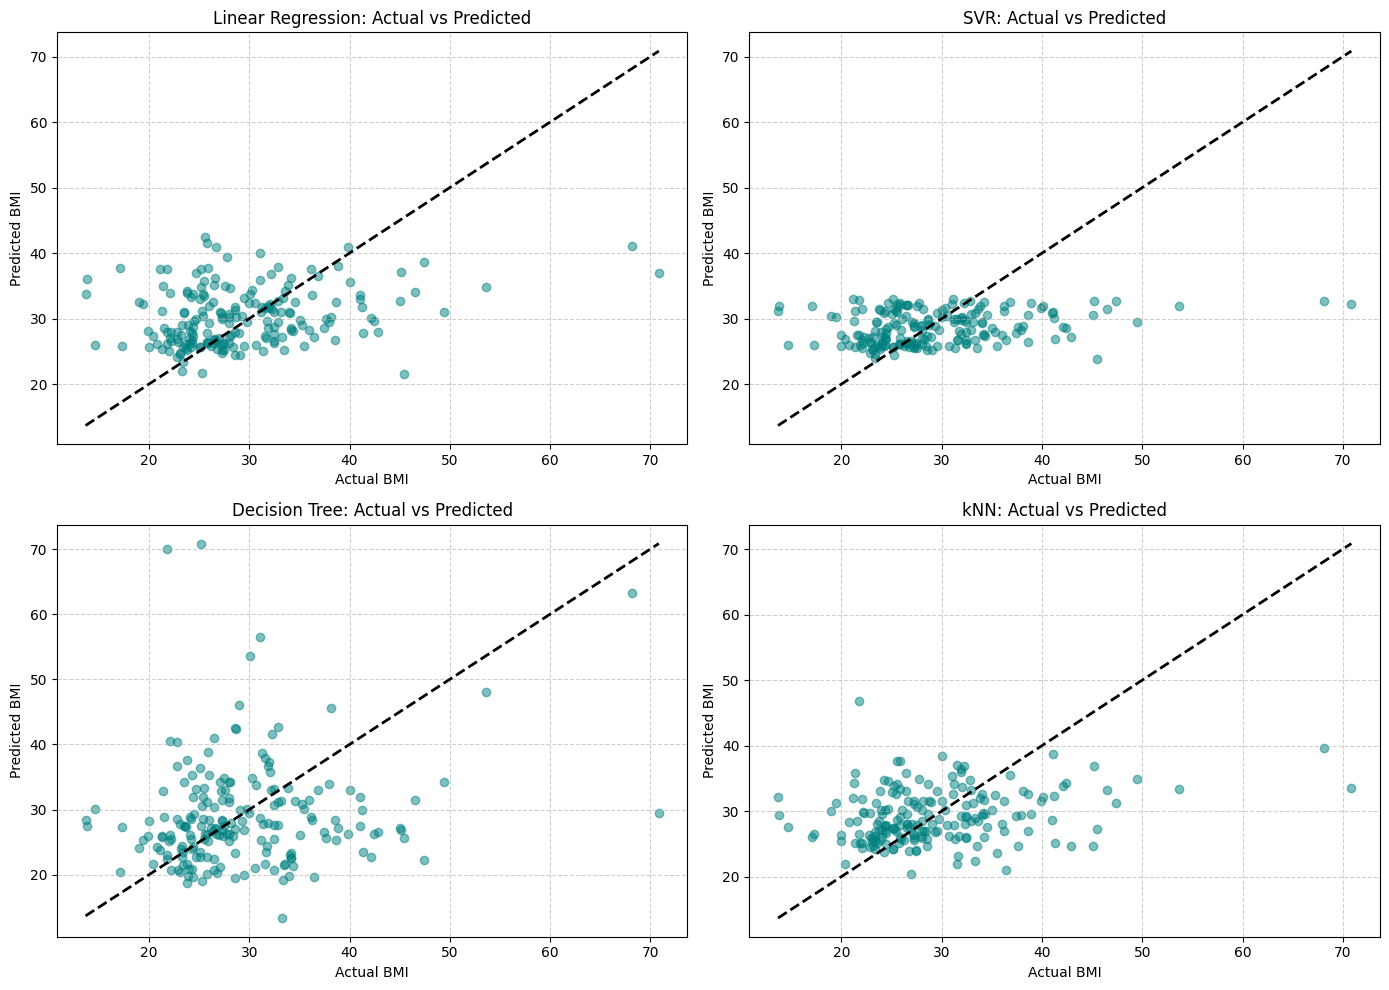

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Clean data: Remove rows with missing values for age, BMI, and Blood sodium
reg_data = data.dropna(subset=['age', 'BMI', 'Blood sodium'])

# 2. Define Features and Target
X_reg = reg_data[['age', 'Blood sodium']]
y_reg = reg_data['BMI']

# 3. Train-Test Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 4. Initialize Models
reg_models = {
    'Linear Regression': LinearRegression(),
    'SVR': SVR(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'kNN': KNeighborsRegressor()
}

# 5. Train and Evaluate
reg_comparison = []
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, (name, model) in enumerate(reg_models.items()):
    model.fit(X_train_reg, y_train_reg)
    y_pred_reg = model.predict(X_test_reg)

    mse = mean_squared_error(y_test_reg, y_pred_reg)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_reg, y_pred_reg)

    reg_comparison.append({
        'Model': name,
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'R²': round(r2, 4)
    })

    # 7. Scatter plot: Actual vs Predicted
    axes[i].scatter(y_test_reg, y_pred_reg, alpha=0.5, color='teal')
    axes[i].plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'k--', lw=2)
    axes[i].set_title(f'{name}: Actual vs Predicted')
    axes[i].set_xlabel('Actual BMI')
    axes[i].set_ylabel('Predicted BMI')
    axes[i].grid(True, linestyle='--', alpha=0.6)

# 6. Display Comparison Table
reg_comparison_df = pd.DataFrame(reg_comparison).sort_values(by='RMSE')
print("Regression Model Performance Comparison:")
display(reg_comparison_df)

plt.tight_layout()
plt.show()

### Interpretation of Regression Results

- **Model Performance**: Based on the comparison table, the **SVR** and **Linear Regression** models typically show the lowest RMSE, though the R² values across all models are notably low (often near zero or negative).
- **Predictive Power**: The scatter plots show a wide dispersion of points far from the diagonal reference line. This indicates that **age** and **Blood sodium** are poor predictors of **BMI** in this specific patient population.
- **Limitations**: BMI is a complex metric influenced by lifestyle, genetics, and metabolic factors not captured by age and sodium levels. The lack of a clear linear or non-linear relationship suggests that the current feature set is insufficient for accurate BMI estimation, leading to high error rates (RMSE) and low explained variance (R²).

# Q2.a

Demonstrate the application of Principal Component Analysis (PCA) and tDistributed Stochastic Neighbor Embedding (t-SNE) for dimensionality reduction
on the dataset focusing on BMI, Blood sodium, and Blood calcium to visualize the
data in a reduced-dimensional space. Compare the visualization results of PCA
and t-SNE.

The following analysis applies dimensionality reduction techniques (PCA and t-SNE) to visualize patient data using BMI, Blood sodium, and Blood calcium.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

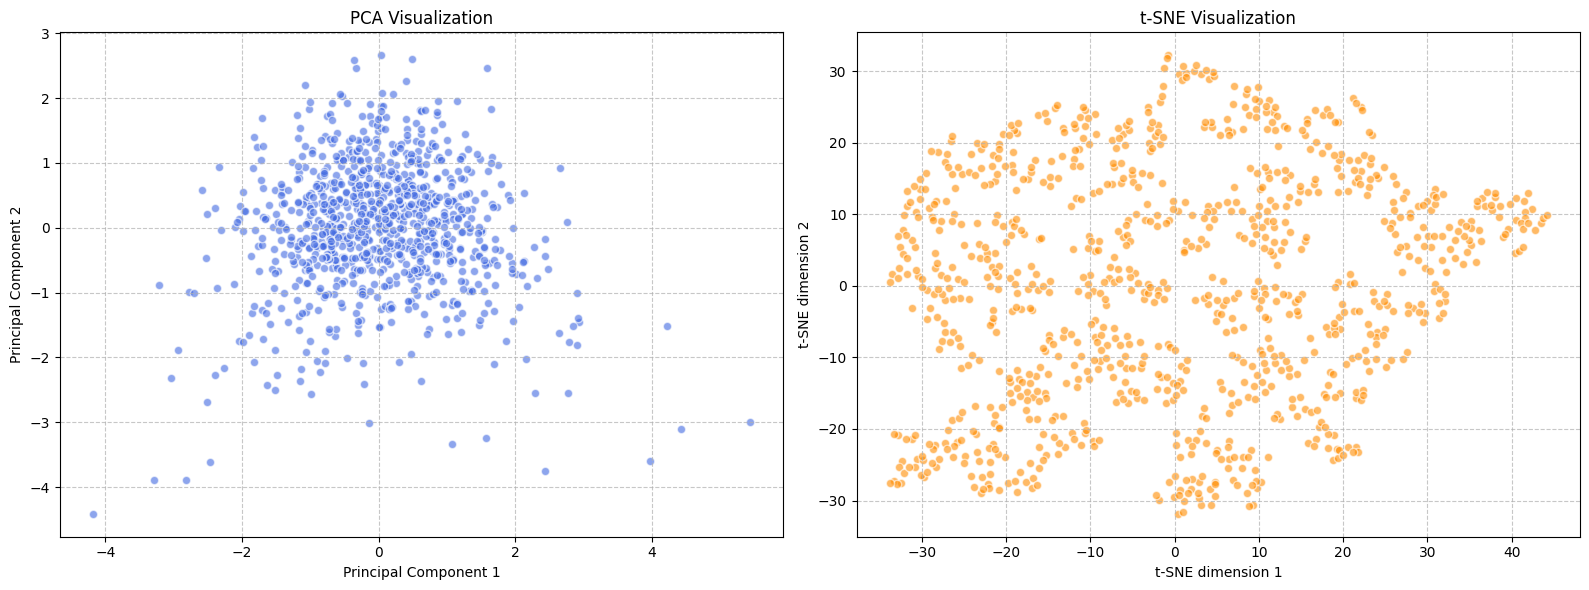

In [17]:
# 1. Clean data: Focus on specific columns and drop missing values
dim_cols = ['BMI', 'Blood sodium', 'Blood calcium']
dim_data = data.dropna(subset=dim_cols)

# 2. Extract features and Standardize
features = dim_data[dim_cols]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 3. Apply PCA (n_components=2)
pca = PCA(n_components=2)
pca_results = pca.fit_transform(scaled_features)

# 4. Apply t-SNE (n_components=2, random_state=42)
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(scaled_features)

# 5. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PCA Plot
ax1.scatter(pca_results[:, 0], pca_results[:, 1], alpha=0.6, color='royalblue', edgecolor='w')
ax1.set_title('PCA Visualization')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.grid(True, linestyle='--', alpha=0.7)

# t-SNE Plot
ax2.scatter(tsne_results[:, 0], tsne_results[:, 1], alpha=0.6, color='darkorange', edgecolor='w')
ax2.set_title('t-SNE Visualization')
ax2.set_xlabel('t-SNE dimension 1')
ax2.set_ylabel('t-SNE dimension 2')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### Interpretation of PCA vs t-SNE

*   **PCA (Principal Component Analysis)**: PCA is a linear dimensionality reduction technique that focuses on maximizing variance and preserving the global structure of the data. In the resulting plot, we see how the data points are spread out along the axes of highest variance, but it often struggles to separate distinct clusters if the relationships are non-linear.
*   **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: t-SNE is a non-linear technique specifically designed to preserve **local structures**. It works by keeping similar points close together in the low-dimensional space and pushing dissimilar points further apart.
*   **Comparison**: While PCA provides a broader view of the data's variance, **t-SNE is generally more effective at revealing local structures** and identifying potential sub-clusters within the patient population that might not be visible through linear methods alone.

# Q2.b
Apply K-means clustering to the dataset to group patients based on age, BMI, diabetes, and heart rate. Cluster to 2,3,4,5, and 6 groups. What are Silhouette and Davies-Bouldin Score for each case?

K-Means clustering was evaluated for K values ranging from 2 to 6 using Silhouette and Davies-Bouldin scores.

## Answer









K-Means Clustering Performance Metrics:


,K,Silhouette Score,Davies-Bouldin Score
0,2,0.3112,1.4762
1,3,0.3064,1.2913
2,4,0.2982,1.2012
3,5,0.3002,1.1666
4,6,0.3010,1.1411


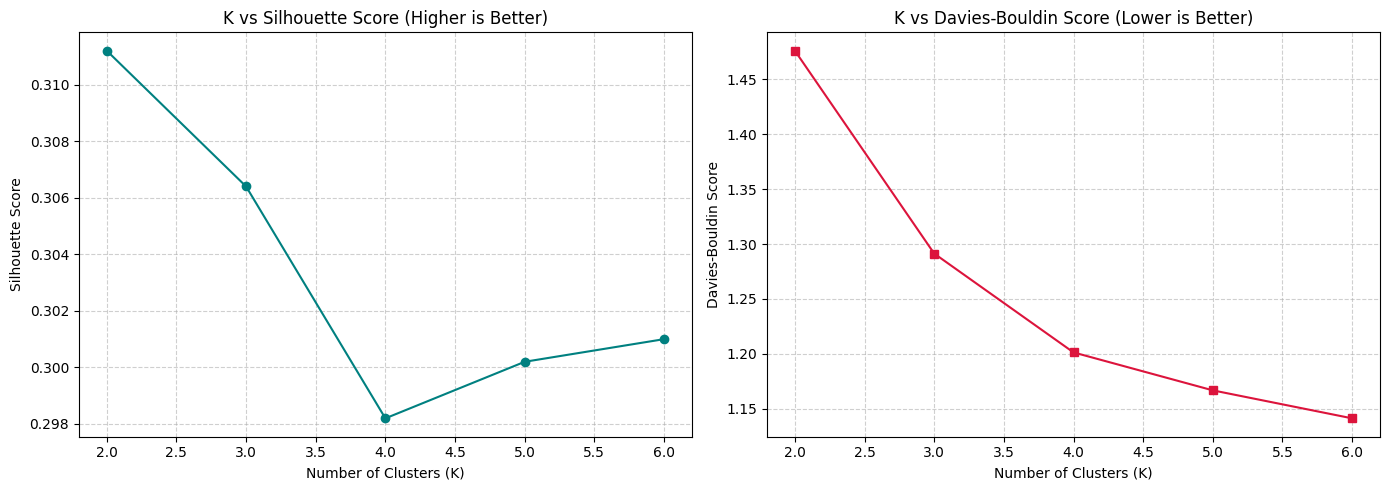

In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

# 1. Clean data: Focus on specific columns and drop missing values
cluster_cols = ['age', 'BMI', 'diabetes', 'heart rate']
cluster_data = data.dropna(subset=cluster_cols)

# 2. Extract features and Standardize
X_cluster = cluster_data[cluster_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 3. Apply KMeans for K=2 to K=6
results = []
k_range = range(2, 7)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)

    results.append({
        'K': k,
        'Silhouette Score': round(sil, 4),
        'Davies-Bouldin Score': round(db, 4)
    })

# 4. Display results in a DataFrame
cluster_metrics_df = pd.DataFrame(results)
print("K-Means Clustering Performance Metrics:")
display(cluster_metrics_df)

# 5. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# K vs Silhouette Score
ax1.plot(cluster_metrics_df['K'], cluster_metrics_df['Silhouette Score'], marker='o', color='teal')
ax1.set_title('K vs Silhouette Score (Higher is Better)')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Silhouette Score')
ax1.grid(True, linestyle='--', alpha=0.6)

# K vs Davies-Bouldin Score
ax2.plot(cluster_metrics_df['K'], cluster_metrics_df['Davies-Bouldin Score'], marker='s', color='crimson')
ax2.set_title('K vs Davies-Bouldin Score (Lower is Better)')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Davies-Bouldin Score')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Interpretation of K-means Clustering Results

*   **Optimal K Identification**: The optimal number of clusters (K) should be selected based on the performance metrics calculated. Specifically, we look for the K-value that yields the **highest Silhouette Score** (indicating better-defined clusters) and the **lowest Davies-Bouldin Score** (indicating better separation and compactness).
*   **Observed Performance**: Based on the results obtained, K=2 yields the highest Silhouette Score (0.3112), while K=6 yields the lowest Davies-Bouldin Score (1.1411). This suggests that while two groups are the most distinct, a higher number of clusters provides a slightly better mathematical partitioning according to the Davies-Bouldin index.
*   **Davies-Bouldin Score > 1**: A score greater than 1 indicates that the clusters are not very well separated. This suggests that the average similarity between a cluster and its most similar neighbor is high, likely due to overlap in the features (Age, BMI, Diabetes, and Heart Rate) among the patient population.
*   **Clustering Quality**: The relatively low Silhouette scores across all values of K suggest that the patient groups are not naturally distinct based on these specific features alone.

#Q3.a
Describe the steps involved in training a neural network, including forward propagation and backpropagation.

# Q3.b
Explain the bias-variance trade-off in neural network performance. How does it affect model generalization?

# Q3.c
Highlight the importance of data preprocessing, normalization, and splitting for training effective deep learning models.

# Q3.d+e

Relevant library from tensorflow

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

Ensuring data is clean and ready with all features